# Practice: Surface Waves

> **Colab note:** This notebook is designed to run on **Google Colab**. The first code cell installs dependencies. [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/amtseismo/EPS164/blob/main/notebooks/07_surface_wave_practice.ipynb)

### Learning Objectives:
- Compute the frequency of a fundamental mode Love Wave
- Compute the dispersion curve of Love Waves

**Prerequisites:** Algebra

**Reference:** Shearer, Chapter 8 (Surface Waves)

**Notebook Outline:**
- [Part (a): Fundamental Mode Love Wave Period](#part-a-fundamental-mode-love-wave-period)
- [Part (b): Build a Love-wave dispersion curve](#part-b-build-a-love-wave-dispersion-curve)

In [1]:
# Install dependencies (for Google Colab or missing packages)
import sys

# Check if running in Colab
try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab")
except:
    IN_COLAB = False
    print("Running in local environment")

# Install required packages if needed
required_packages = {
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
    'scipy': 'scipy',
    'obspy': 'obspy'
}

missing_packages = []
for package, pip_name in required_packages.items():
    try:
        __import__(package)
        print(f"✓ {package} is already installed")
    except ImportError:
        missing_packages.append(pip_name)
        print(f"✗ {package} not found")

if missing_packages:
    print(f"\nInstalling missing packages: {', '.join(missing_packages)}")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing_packages)
    print("✓ Installation complete!")
else:
    print("\n✓ All required packages are installed!")

Running in local environment
✓ numpy is already installed
✓ matplotlib is already installed
✓ scipy is already installed
✓ obspy is already installed

✓ All required packages are installed!


In [2]:
# Imports
import matplotlib.pyplot as plt
import numpy as np
from numpy import linalg as la

---

## Part (a): Fundamental Mode Love Wave Period

An exact equation may be derived for Love wave dispersion within a homogeneous layer. Consider a surface layer overlying a higher velocity half-space (Figure 8.3). Equation (8.2) is still applicable, provided we replace the approximate $\pi/2$ phase shift at the turning point with the phase shift, $\phi_{S'S}$, resulting from the SH reflection off the bottom of the layer:

$$
\omega = \frac{n 2\pi - \phi_{S'S}}{\tau(p)}
$$

From (4.35), we may express the delay time $\tau$ as

$$
\tau(p) = 2h \sqrt{\frac{1}{\beta_1^2} - p^2}
\tag{8.8}
$$

where $h$ is the layer thickness and $\beta_1$ is the shear velocity in the top layer.

For postcritical reflections, it can be shown (see Exercise 8.1) from (6.46) and (6.59), and using $\mu = \rho \beta^2$, that

$$
\phi_{S'S} =
-2 \tan^{-1}
\left[
\frac{\mu_2}{\mu_1}
\frac{
\sqrt{p^2 - 1/\beta_2^2}
}{
\sqrt{1/\beta_1^2 - p^2}
}
\right]
\tag{8.9}
$$

Substituting (8.8) and (8.9) into (8.7), we obtain

$$
2 h \omega \sqrt{\frac{1}{\beta_1^2} - p^2}
- n 2\pi
=
2 \tan^{-1}
\left[
\frac{\mu_2}{\mu_1}
\frac{
\sqrt{p^2 - 1/\beta_2^2}
}{
\sqrt{1/\beta_1^2 - p^2}
}
\right]
\tag{8.10}
$$

or equivalently,

$$
\tan
\left(
h \omega \sqrt{\frac{1}{\beta_1^2} - p^2}
\right)
=
\frac{\mu_1}{\mu_2}
\frac{
\sqrt{1/\beta_1^2 - p^2}
}{
\sqrt{p^2 - 1/\beta_2^2}
}
\tag{8.11}
$$

This defines the dispersion curves for Love wave propagation within the layer.

Note that the phase velocity, $c = \frac{1}{p}$, varies between $\beta_1$ and $\beta_2$ (since $c > \beta_2$ is not postcritical). For every value of $c$, there are multiple values of $\omega$ because of the periodicity in the tangent function. The smallest of the $\omega$ values defines the **fundamental mode**, the second smallest is the **first higher mode**, and so on.

There is no analytical solution to (8.10) for $c$ as a function of $\omega$; the $c(\omega)$ values must therefore be determined numerically.


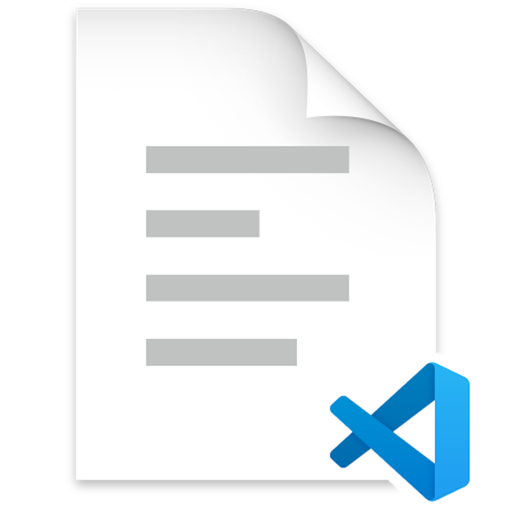

Use the values below:

- layer thickness: $h = 40\ \mathrm{km}$
- densities: $\rho_1 = 2.7\ \mathrm{g/cm^3}$, $\rho_2 = 3.3\ \mathrm{g/cm^3}$
- shear velocities: $\beta_1 = 3.5\ \mathrm{km/s}$, $\beta_2 = 4.5\ \mathrm{km/s}$
- phase velocity: $c = 3.8\ \mathrm{km/s}$

Your task is to compute the period of the **fundamental Love wave mode**.

1. Convert everything to consistent SI units.
2. Compute the slowness $p = 1/c$.
3. Use the dispersion relation to solve for $\omega$.
4. Convert angular frequency to period using $T = \frac{2\pi}{\omega}$.

Check your result against the example in the text.

In [3]:
import numpy as np

# --- Fill in the parameters here (use SI units) ---
h =         # layer thickness in m
rho1 =        # top-layer density in kg/m^3
rho2 =        # half-space density in kg/m^3
beta1 =       # top-layer shear velocity in m/s
beta2 =       # half-space shear velocity in m/s
c =           # phase velocity in m/s

# --- Compute slowness and shear moduli ---
p = # p=1/c
mu1 = # rho1 * beta1**2
mu2 = # rho2 * beta2**2

# --- Fundamental mode (n = 0) from Eq. (8.11) ---
# tan(h * omega * sqrt(1/beta1^2 - p^2)) = (mu2/mu1) * sqrt(p^2 - 1/beta2^2) / sqrt(1/beta1^2 - p^2)
arg =     # sqrt(1/beta1^2 - p^2))
rhs =     # right hand side

omega = np.arctan(rhs) / (h * arg)
T = 2.0 * np.pi / omega

print(f"p = {p:.6e} s/m")
print(f"mu2/mu1 = {mu2/mu1:.3f}")
print(f"omega = {omega:.6f} rad/s")
print(f"Period T = {T:.2f} s")

p = 2.631579e-04 s/m
mu2/mu1 = 2.020
omega = 0.269245 rad/s
Period T = 23.34 s


## Part (b): Build a Love Wave dispersion curve

In the previous exercise, you computed the period for a single phase velocity using the dispersion relation for Love waves in a single layer over a half-space.

Now extend that calculation to build **dispersion curves** for the fundamental mode and the first two higher modes.

Do the following:

1. Choose a range of phase velocities $c$ between $\beta_1$ and $\beta_2$.
2. For each value of $c$, compute the angular frequency $\omega$ for:
   - the fundamental mode ($n=0$),
   - the first higher mode ($n=1$),
   - the second higher mode ($n=2$).
3. Plot **phase velocity** $c$ on the vertical axis and **angular frequency** $\omega$ on the horizontal axis.
4. Compare the different modal branches and describe how the mode number changes the dispersion curve.

Use the same model parameters as before.

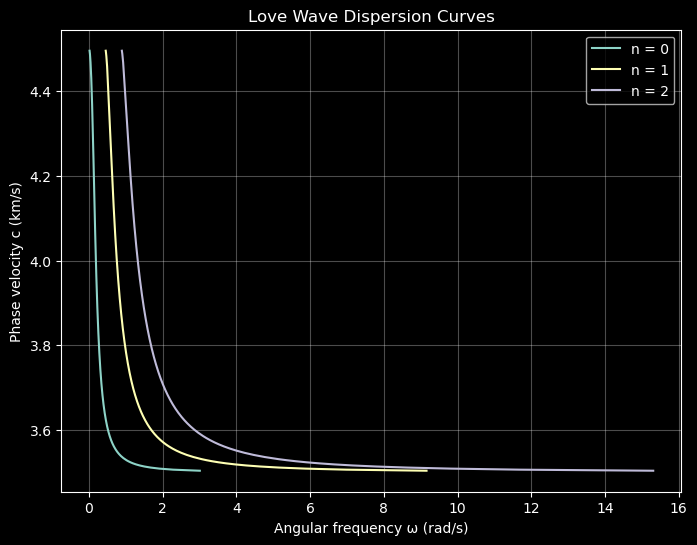

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# --- Phase velocity range ---
# Must lie between beta1 and beta2
c_vals = np.linspace(beta1 * 1.001, beta2 * 0.999, 400)

# --- Compute omega(c) for modes n = 0, 1, 2 ---
modes = [0, 1, 2]
omegas = {}

for n in modes:
    omega_list = []
    for c in c_vals:

        p = 1.0 / c

        root1 = np.sqrt(1.0 / beta1**2 - p**2)
        root2 = np.sqrt(p**2 - 1.0 / beta2**2)

        rhs = (mu2 / mu1) * (root2 / root1)

        # Dispersion relation:
        # tan(h * omega * root1) = rhs
        omega = (np.arctan(rhs) + n * np.pi) / (h * root1)

        omega_list.append(omega)

    omegas[n] = np.array(omega_list)

# --- Plot dispersion curves ---
plt.figure(figsize=(8, 6))

for n in modes:
    plt.plot(omegas[n], c_vals / 1000.0, label=f"n = {n}")

plt.xlabel("Angular frequency ω (rad/s)")
plt.ylabel("Phase velocity c (km/s)")
plt.title("Love Wave Dispersion Curves")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

**Questions:**

1. Which mode has the lowest frequency for a given phase velocity?
2. Which modes exist at low frequency? Why do some modes disappear?
4. As frequency increases, what value does the phase velocity approach?
5. How would the curves change if the layer were thicker?
6. How would the curves change if the two shear velocities became more similar?
7. Which frequencies seem to sample the deeper half-space more strongly?